This code is needed to run only one time. dataset will get downloaded

In [1]:
!kaggle datasets download -d shreelakshmigp/cedardataset
!unzip -q cedardataset.zip -d data/raw/cedar_raw

'chmod' is not recognized as an internal or external command,
operable program or batch file.


Dataset URL: https://www.kaggle.com/datasets/shreelakshmigp/cedardataset
License(s): unknown




  0%|          | 0.00/242M [00:00<?, ?B/s]
  0%|          | 1.00M/242M [00:01<06:08, 687kB/s]
  1%|          | 2.00M/242M [00:01<03:03, 1.38MB/s]
  1%|          | 3.00M/242M [00:01<01:53, 2.21MB/s]
  2%|▏         | 5.00M/242M [00:02<00:59, 4.16MB/s]
  3%|▎         | 7.00M/242M [00:02<00:38, 6.42MB/s]
  4%|▎         | 9.00M/242M [00:02<00:29, 8.39MB/s]
  5%|▍         | 11.0M/242M [00:02<00:22, 10.7MB/s]
  5%|▌         | 13.0M/242M [00:02<00:20, 11.9MB/s]
  6%|▌         | 15.0M/242M [00:02<00:17, 13.6MB/s]
  7%|▋         | 17.0M/242M [00:02<00:15, 14.8MB/s]
  8%|▊         | 19.0M/242M [00:02<00:14, 15.9MB/s]
  9%|▊         | 21.0M/242M [00:02<00:14, 16.1MB/s]
  9%|▉         | 23.0M/242M [00:03<00:14, 15.7MB/s]
 11%|█         | 26.0M/242M [00:03<00:14, 15.6MB/s]
 12%|█▏        | 29.0M/242M [00:03<00:12, 17.7MB/s]
 13%|█▎        | 31.0M/242M [00:03<00:12, 17.3MB/s]
 14%|█▎        | 33.0M/242M [00:03<00:14, 15.0MB/s]
 14%|█▍        | 35.0M/242M [00:04<00:17, 12.4MB/s]
 16%|█▌        | 38.0

In [49]:
from IPython.display import Image, display

def show_image(image_path):
    """
    This function takes an image file path and displays the image in a Jupyter notebook.
    
    Parameters:
    image_path (str): The file path to the PNG image.
    """
    display(Image(filename=image_path))

### 1. Importing Libraries & unzipping data 

In [22]:
import zipfile
import os, random, shutil
import cv2, torch
from torch.utils.data import Dataset
import torch.nn as nn
import torch.nn.functional as F
from torchvision.models import resnet18, ResNet18_Weights

from sklearn.metrics import roc_curve, accuracy_score
import numpy as np
from tqdm import tqdm

In [2]:
"""
DO NOT RUN THIS CELL AGAIN IF YOU HAVE ALREADY UNZIPPED THE DATASET
"""

zip_file_path = 'cedardataset.zip'
dest_dir = 'data/raw/cedar_raw'
os.makedirs(dest_dir, exist_ok=True)

# Unzip the file
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(dest_dir)

print(f"Unzipped the dataset to {dest_dir}")


Unzipped the dataset to data/raw/cedar_raw


### 2. Train Test Split (Writer wise)

In [5]:
ORG = "data/raw/cedar_raw/signatures/full_org"
FORG = "data/raw/cedar_raw/signatures/full_forg"
BASE = "data/split"

def wid(fname): return fname.split("_")[1]
def is_img(f): return f.lower().endswith(".png")

writers = sorted({wid(f) for f in os.listdir(ORG) if is_img(f)})
random.shuffle(writers)

train_w, val_w, test_w = writers[:35], writers[35:45], writers[45:]

for split in ["train","val","test"]:
    for t in ["org","forg"]:
        os.makedirs(f"{BASE}/{split}/{t}", exist_ok=True)

def move(src, dst_map):
    for f in os.listdir(src):
        if not is_img(f): continue
        w = wid(f)
        for key, dst in dst_map.items():
            if w in key:
                shutil.copy(os.path.join(src,f), dst)

move(ORG,  {tuple(train_w):f"{BASE}/train/org",
            tuple(val_w):f"{BASE}/val/org",
            tuple(test_w):f"{BASE}/test/org"})

move(FORG, {tuple(train_w):f"{BASE}/train/forg",
            tuple(val_w):f"{BASE}/val/forg",
            tuple(test_w):f"{BASE}/test/forg"})


### 3. Image Pre-processing (this function will get used all time)

In [14]:
def preprocess_image(path, device):
    img = cv2.imread(path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    _, th = cv2.threshold(
        gray, 0, 255,
        cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
    )

    coords = cv2.findNonZero(th)
    x,y,w,h = cv2.boundingRect(coords)
    crop = th[y:y+h, x:x+w]

    crop = cv2.resize(crop, (224,224)) / 255.0
    tensor = torch.tensor(crop).float().unsqueeze(0).unsqueeze(0).to(device)
    return tensor


### 4. Writer Dataset

In [15]:
class WriterDataset(Dataset):
    def __init__(self, root, device):
        self.samples = []
        self.writer_map = {}
        self.device = device

        wid_idx = 0
        for f in os.listdir(root):
            w = f.split("_")[1]
            if w not in self.writer_map:
                self.writer_map[w] = wid_idx
                wid_idx += 1
            self.samples.append((os.path.join(root,f), self.writer_map[w]))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = preprocess_image(path, self.device)
        return img.squeeze(0), label


### 5. WriterNet (classification model)

```
Input Signature (224×224 grayscale)
        ↓
ResNet18 Backbone
        ↓
512-d Feature Vector
        ↓
Embedding Layer (256-d)
        ↓
├── Classifier (training only)
└── Embedding (used for verification)


In [ ]:
class WriterNet(nn.Module):
    def __init__(self, n_writers):
        super().__init__()
        base = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
        base.conv1 = nn.Conv2d(1,64,7,2,3,bias=False)

        self.backbone = nn.Sequential(*list(base.children())[:-1])
        self.embedding = nn.Linear(512,256) # output from backbone is 512-dim, we reduce it to 256-dim for better generalization
        self.classifier = nn.Linear(256,n_writers) # Supervised representation learning

    """
    Input -> [1, 224, 224]
    Backbone -> [512, 1, 1]
    Flatten -> [512]
    Embedding layer -> [256]
    Classifier -> [n_writers]
    """
    
    def forward(self,x):
        x = self.backbone(x).flatten(1)
        emb = self.embedding(x)
        logits = self.classifier(emb)
        return logits, emb


### 6. Training Loop

In [17]:
device = "cpu"

train_ds = WriterDataset("data/split/train/org", device)
train_dl = torch.utils.data.DataLoader(train_ds, batch_size=32, shuffle=True)

model = WriterNet(len(train_ds.writer_map)).to(device)
opt = torch.optim.Adam(model.parameters(), lr=1e-4)
loss_fn = nn.CrossEntropyLoss()

for epoch in range(10):
    total = 0
    for x,y in train_dl:
        x,y = x.to(device), y.to(device)
        logits,_ = model(x)
        loss = loss_fn(logits,y)

        opt.zero_grad()
        loss.backward()
        opt.step()
        total += loss.item()
    print(f"Epoch {epoch+1} | Loss {total/len(train_dl):.4f}")


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\Arya/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 202MB/s]


Epoch 1 | Loss 2.5329
Epoch 2 | Loss 0.8416
Epoch 3 | Loss 0.2525
Epoch 4 | Loss 0.1096
Epoch 5 | Loss 0.0619
Epoch 6 | Loss 0.0399
Epoch 7 | Loss 0.0324
Epoch 8 | Loss 0.0240
Epoch 9 | Loss 0.0195
Epoch 10 | Loss 0.0174


### 7. Convert to Embedding Model (Solution B core)

In [18]:
class EmbeddingModel(nn.Module):
    def __init__(self, writer_model):
        super().__init__()
        self.backbone = writer_model.backbone
        self.embedding = writer_model.embedding

    def forward(self,x):
        x = self.backbone(x).flatten(1)
        x = self.embedding(x)
        return F.normalize(x,p=2,dim=1)


### 8. Build Genuine Embedding DB

In [19]:
embed_model = EmbeddingModel(model).to(device).eval()
embedding_db = {}

ORG_TEST = "data/split/test/org"

for f in os.listdir(ORG_TEST):
    w = f.split("_")[1]
    img = preprocess_image(os.path.join(ORG_TEST,f), device)
    with torch.no_grad():
        emb = embed_model(img).cpu()
    embedding_db.setdefault(w, []).append(emb)


### 9.1 Building test pairs

In [20]:
def build_test_pairs(org_dir, forg_dir):
    pairs = []

    # Genuine–Genuine (label = 1)
    for f in os.listdir(org_dir):
        if not f.endswith(".png"):
            continue

        writer = f.split("_")[1]
        g_list = [x for x in os.listdir(org_dir) if f"_{writer}_" in x]

        if len(g_list) < 2:
            continue

        g1, g2 = random.sample(g_list, 2)
        pairs.append((
            os.path.join(org_dir, g1),
            os.path.join(org_dir, g2),
            1
        ))

    # Genuine–Forgery (label = 0)
    for f in os.listdir(forg_dir):
        if not f.endswith(".png"):
            continue

        writer = f.split("_")[1]
        g_list = [x for x in os.listdir(org_dir) if f"_{writer}_" in x]

        if not g_list:
            continue

        g = random.choice(g_list)
        pairs.append((
            os.path.join(org_dir, g),
            os.path.join(forg_dir, f),
            0
        ))

    return pairs


### 9.2 Extracting embeddings

In [ ]:
def get_embedding(img_path):
    img = preprocess_image(img_path, device)
    with torch.no_grad():
        emb = embed_model(img)
    return emb.cpu()


### 9.3 Test Script

In [ ]:
test_pairs = build_test_pairs(
    "data/split/test/org",
    "data/split/test/forg"
)

scores = []
labels = []

for p1, p2, y in tqdm(test_pairs):
    e1 = get_embedding(p1)
    e2 = get_embedding(p2)

    dist = F.pairwise_distance(e1, e2).item()
    score = -dist  # higher = more similar

    scores.append(score)
    labels.append(y)

fpr, tpr, thresholds = roc_curve(labels, scores)
best_idx = np.argmax(tpr - fpr)
best_threshold = thresholds[best_idx]

preds = [1 if s > best_threshold else 0 for s in scores]

print("Test Accuracy:", accuracy_score(labels, preds))
print("Best Threshold:", best_threshold)

100%|██████████| 480/480 [00:55<00:00,  8.70it/s]

Test Accuracy: 0.8020833333333334
Best Threshold: -0.6085474491119385


### 10. Distance Distribution

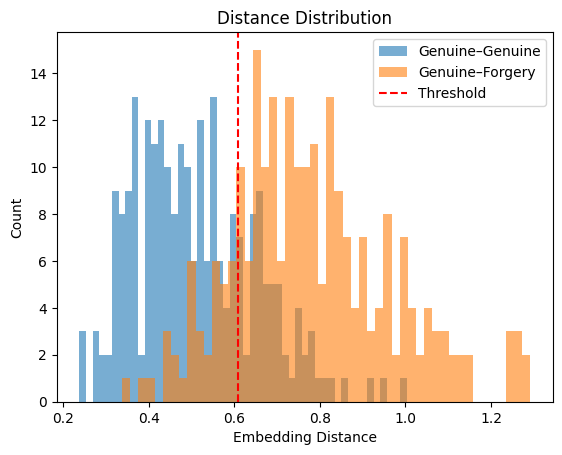

In [24]:
import matplotlib.pyplot as plt

genuine_dists = []
forged_dists = []

for p1, p2, y in test_pairs:
    e1 = get_embedding(p1)
    e2 = get_embedding(p2)
    dist = F.pairwise_distance(e1, e2).item()

    if y == 1:
        genuine_dists.append(dist)
    else:
        forged_dists.append(dist)

plt.hist(genuine_dists, bins=50, alpha=0.6, label="Genuine-Genuine")
plt.hist(forged_dists, bins=50, alpha=0.6, label="Genuine-Forgery")
plt.axvline(-best_threshold, color="red", linestyle="--", label="Threshold")
plt.legend()
plt.xlabel("Embedding Distance")
plt.ylabel("Count")
plt.title("Distance Distribution")
plt.show()


### 11. Inference (Genuine Vs Forged)

In [25]:
def verify_signature(img_path, writer_id, threshold):
    if writer_id not in embedding_db:
        return "UNKNOWN_WRITER", None

    img = preprocess_image(img_path, device)
    with torch.no_grad():
        test_emb = embed_model(img).cpu()

    ref_embs = torch.cat(embedding_db[writer_id])
    dist = F.pairwise_distance(test_emb, ref_embs).mean().item()

    decision = "GENUINE" if dist < -threshold else "FORGED"
    return decision, dist


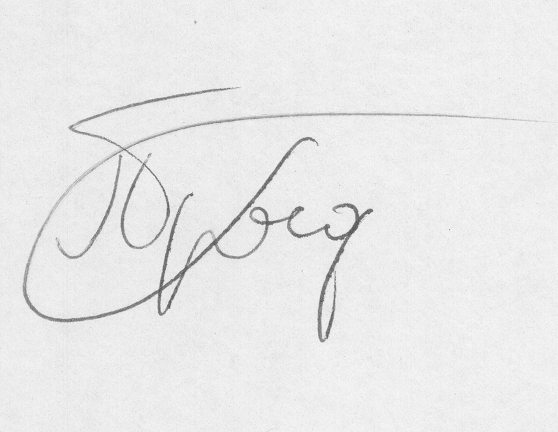

('GENUINE', 0.571160614490509)


In [50]:
test_img = "data/split/test/org/original_8_1.png"
writer_id = "8"

show_image(test_img)
print(verify_signature(test_img, writer_id, best_threshold))


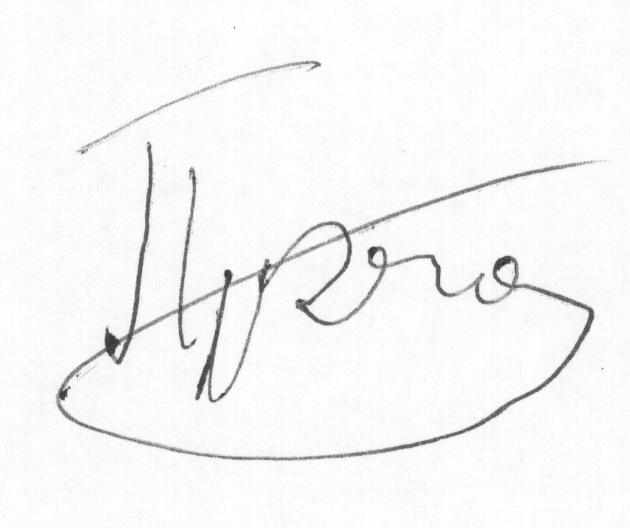

('FORGED', 0.7579498887062073)


In [51]:
test_img = "data/split/test/forg/forgeries_8_1.png"
writer_id = "8"

show_image(test_img)
print(verify_signature(test_img, writer_id, best_threshold))

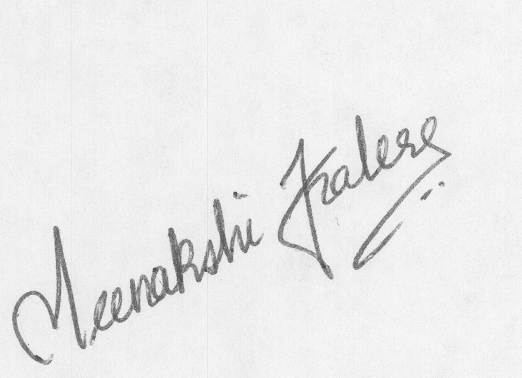

('GENUINE', 0.46435269713401794)


In [52]:
test_img = "data/split/test/org/original_30_1.png"
writer_id = "30"

show_image(test_img)
print(verify_signature(test_img, writer_id, best_threshold))


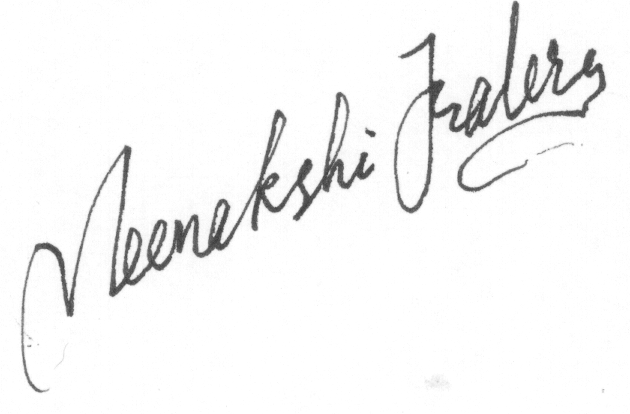

('FORGED', 0.6990588307380676)


In [53]:
test_img = "data/split/test/forg/forgeries_30_1.png"
writer_id = "30"

show_image(test_img)
print(verify_signature(test_img, writer_id, best_threshold))


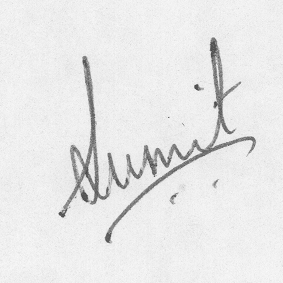

('GENUINE', 0.3634956181049347)


In [60]:
test_img = "data/split/test/org/original_19_21.png"
writer_id = "19"

show_image(test_img)
print(verify_signature(test_img, writer_id, best_threshold))


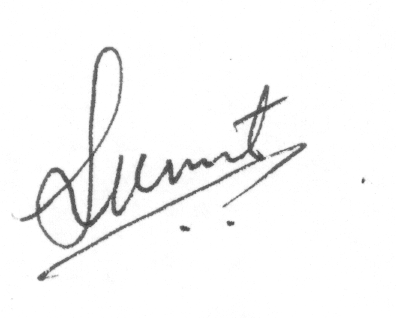

('FORGED', 0.7743350863456726)


In [57]:
test_img = "data/split/test/forg/forgeries_19_3.png"
writer_id = "19"

show_image(test_img)
print(verify_signature(test_img, writer_id, best_threshold))


## Triplet Fine-Tuning

In [66]:
class TripletFineTuneDS(Dataset):
    def __init__(self, org_dir, forg_dir):
        self.org = {}
        self.forg = {}

        for f in os.listdir(org_dir):
            w = f.split("_")[1]
            self.org.setdefault(w, []).append(os.path.join(org_dir, f))

        for f in os.listdir(forg_dir):
            w = f.split("_")[1]
            self.forg.setdefault(w, []).append(os.path.join(forg_dir, f))

        self.writers = list(self.org.keys())

    def __len__(self):
        return 300

    def __getitem__(self, idx):
        w = random.choice(self.writers)
        a, p = random.sample(self.org[w], 2)
        n = random.choice(self.forg[w])

        return (
            preprocess_image(a, device).squeeze(0),
            preprocess_image(p, device).squeeze(0),
            preprocess_image(n, device).squeeze(0)
        )


In [67]:
triplet_ds = TripletFineTuneDS(
    "data/split/train/org",
    "data/split/train/forg"
)

triplet_dl = torch.utils.data.DataLoader(triplet_ds, batch_size=16, shuffle=True)

triplet_loss = torch.nn.TripletMarginLoss(margin=0.5)
optimizer = torch.optim.Adam(embed_model.embedding.parameters(), lr=1e-5)

for epoch in range(6):
    total = 0
    for a, p, n in tqdm(triplet_dl):
        a, p, n = a.to(device), p.to(device), n.to(device)

        ea = embed_model(a)
        ep = embed_model(p)
        en = embed_model(n)

        loss = triplet_loss(ea, ep, en)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total += loss.item()

    print(f"Triplet Epoch {epoch+1} | Loss {total/len(triplet_dl):.4f}")


100%|██████████| 19/19 [02:07<00:00,  6.69s/it]


Triplet Epoch 1 | Loss 0.1497


100%|██████████| 19/19 [02:09<00:00,  6.83s/it]


Triplet Epoch 2 | Loss 0.1296


100%|██████████| 19/19 [02:13<00:00,  7.04s/it]


...

Triplet Epoch 4 | Loss 0.1371


100%|██████████| 19/19 [02:14<00:00,  7.10s/it]


Triplet Epoch 5 | Loss 0.1296


100%|██████████| 19/19 [02:15<00:00,  7.13s/it]

Triplet Epoch 6 | Loss 0.1379


### Repeting step 8-11

In [68]:
##------------------------------------------STEP 8--------------------------------------------
embed_model = EmbeddingModel(model).to(device).eval()
embedding_db_2 = {}

ORG_TEST = "data/split/test/org"

for f in os.listdir(ORG_TEST):
    w = f.split("_")[1]
    img = preprocess_image(os.path.join(ORG_TEST,f), device)
    with torch.no_grad():
        emb = embed_model(img).cpu()
    embedding_db_2.setdefault(w, []).append(emb)

##------------------------------------------STEP 9--------------------------------------------

test_pairs_2 = build_test_pairs(
    "data/split/test/org",
    "data/split/test/forg"
)

scores = []
labels = []

for p1, p2, y in tqdm(test_pairs_2):
    e1 = get_embedding(p1)
    e2 = get_embedding(p2)

    dist = F.pairwise_distance(e1, e2).item()
    score = -dist  # higher = more similar

    scores.append(score)
    labels.append(y)

fpr, tpr, thresholds = roc_curve(labels, scores)
best_idx = np.argmax(tpr - fpr)
best_threshold = thresholds[best_idx]

preds = [1 if s > best_threshold else 0 for s in scores]

print("Test Accuracy:", accuracy_score(labels, preds))
print("Best Threshold:", best_threshold)



100%|██████████| 480/480 [00:52<00:00,  9.07it/s]

Test Accuracy: 0.7875
Best Threshold: -0.6400843262672424


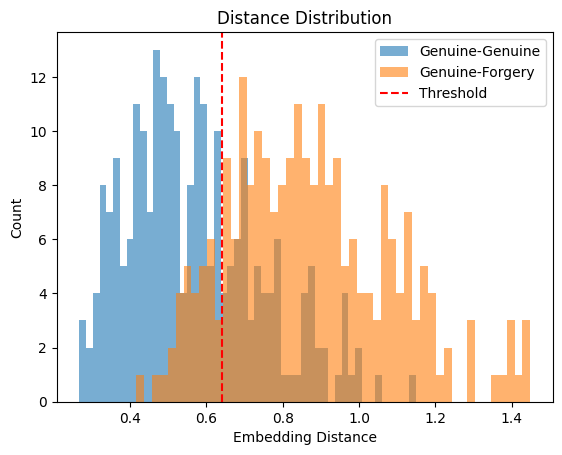

In [69]:
import matplotlib.pyplot as plt

genuine_dists = []
forged_dists = []

for p1, p2, y in test_pairs_2:
    e1 = get_embedding(p1)
    e2 = get_embedding(p2)
    dist = F.pairwise_distance(e1, e2).item()

    if y == 1:
        genuine_dists.append(dist)
    else:
        forged_dists.append(dist)

plt.hist(genuine_dists, bins=50, alpha=0.6, label="Genuine-Genuine")
plt.hist(forged_dists, bins=50, alpha=0.6, label="Genuine-Forgery")
plt.axvline(-best_threshold, color="red", linestyle="--", label="Threshold")
plt.legend()
plt.xlabel("Embedding Distance")
plt.ylabel("Count")
plt.title("Distance Distribution")
plt.show()


As Triplet Fine Tuning did not helped that much which can be of multiple reasons, we can finalize the Stage-1 traing model & embeddings as of now 

In [72]:
import torch
import pickle
import os

os.makedirs("artifacts", exist_ok=True)

torch.save(
    embed_model.state_dict(),
    "artifacts/signature_embedder.pth")
print("✅ Saved signature_embedder.pth")


with open("artifacts/embedding_db.pkl", "wb") as f:
    pickle.dump(embedding_db, f)
print("✅ Saved embedding_db.pkl")



✅ Saved signature_embedder.pth
✅ Saved embedding_db.pkl
